CSCI580 Final Project Group 9

Imports
Source:
- Final Project Slides: project requires PyTorch, MNIST, custom PNG data, accuracy statistics, F1-score, and confusion matrix.
- PerfEval slides: model performance metrics.
- Files: BuildNN-1.ipynb and LoadImage.ipynb

In [1]:
import os                           # For file/directory handling
import random                       # For reproducibility
from collections import defaultdict # For grouping

import numpy as np                  # Numerical operations
import matplotlib.pyplot as plt     # Plotting graphs
from IPython.display import display

from PIL import Image               # Image loading

import torch                        # Core PyTorch library
import torch.nn as nn               # Neural network modules
import torch.optim as optim         # Optimizers

from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import datasets, transforms  # Datasets and preprocessing

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report
)

Reproducibility + Device Setup
Source:
- General PyTorch setup

In [2]:
# Locking seed to group number for consistent data
seed = 9

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


Image Transform / Preprocessing
Source:
- Final Project slides, Task 3:
  ToTensor() maps [0,255] -> [0,1]
  Normalize(mean=0.5, std=0.5) maps [0,1] -> [-1,1]

In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

Load MNIST Dataset
Source:
- Final Project slides, page 8:
  trainset = datasets.MNIST(... train=True)
  testset = datasets.MNIST(... train=False)

In [4]:
mnist_train_full = datasets.MNIST(
    root="./MNIST_data",
    train=True,
    download=True,
    transform=transform
)

mnist_test = datasets.MNIST(
    root="./MNIST_data",
    train=False,
    download=True,
    transform=transform
)


Source:
- Model Tuning slides, slide "Training, Validation and Test"
- Model Tuning slides, slide "Training with Validation"


In [5]:
train_size = int(0.8 * len(mnist_train_full))
val_size = len(mnist_train_full) - train_size

mnist_train, mnist_val = random_split(
    mnist_train_full,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(seed)
)

batch_size = 64

train_loader = DataLoader(mnist_train, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(mnist_val, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(mnist_test, batch_size=batch_size, shuffle=False)

print("Training samples:", len(mnist_train))
print("Validation samples:", len(mnist_val))
print("MNIST test samples:", len(mnist_test))

Training samples: 48000
Validation samples: 12000
MNIST test samples: 10000


Custom Project Dataset Loader
Source:
- Final Project slides, Task 1:
  filename format: <label/digit>-<groupID>-<memberID>.png
- Final Project slides, Task 2:
  read PNG files and assign labels
- Final Project slides, Task 3:
  preprocess images using PyTorch transforms

In [6]:
class ProjectDigitDataset(Dataset):
    def __init__(self, folder_path):
        self.folder_path = folder_path

        self.files = [
            f for f in os.listdir(folder_path)
            if f.lower().endswith(".png")
        ]

        self.files.sort()

        self.transform = transforms.Compose([
            transforms.Grayscale(num_output_channels=1),
            transforms.Resize((28, 28)),
            transforms.ToTensor(),
            transforms.Normalize((0.5,), (0.5,))
        ])

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        filename = self.files[idx]

        # Expected filename:
        # <label/digit>-<groupID>-<memberID>.png
        # Example:
        # 3-4-1.png means digit 3, group 4, member 1

        name_without_extension = filename.replace(".png", "")
        parts = name_without_extension.split("-")

        label = int(parts[0])
        group_id = int(parts[1])
        member_id = int(parts[2])

        image_path = os.path.join(self.folder_path, filename)

        image = Image.open(image_path)
        image = self.transform(image)

        return image, label, group_id, member_id, filename


# Change this path if your custom digit folder is elsewhere
custom_digits_folder = "./digits"

if os.path.exists(custom_digits_folder):
    custom_dataset = ProjectDigitDataset(custom_digits_folder)
    custom_loader = DataLoader(custom_dataset, batch_size=32, shuffle=False)
    print("Custom digit samples:", len(custom_dataset))
else:
    custom_dataset = None
    custom_loader = None
    print("No custom digits folder found yet.")

Custom digit samples: 288


MLP Model Definition
Source:
- Final Project slides:
  Must use MLP / fully connected feedforward neural network only.
- BuildTrainNN slides:
  Example architecture uses input 784, hidden layers, output 10.
- Model Tuning slides:
  Architecture hyperparameters include number of layers,
  neurons per layer, activation function, and dropout.

In [7]:
class MLP(nn.Module):
    def __init__(self, network, dropout_rate=0.3):
        super().__init__()

        self.network = network

    def forward(self, x):
        # Flatten 28x28 image into 784 input features.
        x = x.view(x.shape[0], -1)
        return self.network(x)

Count Parameters
Source:
- Final Report requirements:
  include number of neurons, layers, weights, and key hyperparameters.

In [8]:
def count_parameters(model):
    total = 0
    trainable = 0

    for param in model.parameters():
        num = param.numel()
        total += num

        if param.requires_grad:
            trainable += num

    return total, trainable


Training Function
Source:
- BuildTrainNN slides, training main loop:
  - optimizer.zero_grad()
  - output = model(input)
  - loss = loss_fn(output, target)
  - loss.backward()
  - optimizer.step()

In [9]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)

        # Reset gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backpropagation
        loss.backward()
        # Update weights
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        predictions = torch.argmax(outputs, dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

Validation Function

Source:
- Model Tuning slides, slide "Training with Validation":
  - validation phase after each epoch
  - model.eval()
  - disable gradient computation
  - forward pass only
  - compute validation loss and metrics

In [10]:
def validate_one_epoch(model, dataloader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    # Disable gradients
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            predictions = torch.argmax(outputs, dim=1)
            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

Train Model Across Epochs
Source:
- Model Tuning slides:
  track training and validation loss.
- Final Project slides:
  validate while training and tune hyperparameters.

In [11]:
def train_model(model, criterion, optimizer, epochs):
    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []
    
    best_val_loss = float("inf")
    best_model_path = "best_mlp_model.pth"
    
    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            device
        )
    
        val_loss, val_acc = validate_one_epoch(
            model,
            val_loader,
            criterion,
            device
        )
    
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)
    
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), best_model_path)
    
        print(
            f"Epoch [{epoch + 1}/{epochs}] "
            f"Train Loss: {train_loss:.4f}, "
            f"Train Acc: {train_acc:.4f}, "
            f"Val Loss: {val_loss:.4f}, "
            f"Val Acc: {val_acc:.4f}"
        )
    
    model.load_state_dict(torch.load(best_model_path, map_location=device))

    figures = []
    
    # plt.figure()
    fig, ax = plt.subplots()
    plt.plot(range(1, epochs + 1), train_losses, label="Training Loss")
    plt.plot(range(1, epochs + 1), val_losses, label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training vs Validation Loss")
    plt.legend()
    plt.grid(True)
    figures.append(fig)
    plt.close()
    
    # plt.figure()
    fig, ax = plt.subplots()
    plt.plot(range(1, epochs + 1), train_accuracies, label="Training Accuracy")
    plt.plot(range(1, epochs + 1), val_accuracies, label="Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Training vs Validation Accuracy")
    plt.legend()
    plt.grid(True)
    figures.append(fig)    
    plt.close()

    return figures

Plot Training vs Validation Loss
Source:
- Model Tuning slides:
  overfitting slides show training vs validation loss.
- Final Project slides:
  report requires training vs validation loss over iterations.

General Evaluation Function for MNIST Test Data
Source:
- Final Project slides:
  test on MNIST test images.
- PerfEval slides:
  accuracy, error rate, F1-score, and confusion matrix.

In [12]:
def evaluate_mnist_test_data(model, dataloader, device, dataset_name="MNIST Test Data"):
    model.eval()

    all_predictions = []
    all_labels = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            predictions = torch.argmax(outputs, dim=1)

            all_predictions.extend(predictions.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = accuracy_score(all_labels, all_predictions)
    error_rate = 1 - accuracy

    f1_per_digit = f1_score(
        all_labels,
        all_predictions,
        average=None,
        labels=list(range(10)),
        zero_division=0
    )

    cm = confusion_matrix(
        all_labels,
        all_predictions,
        labels=list(range(10))
    )

    print(dataset_name)
    print("Accuracy:", accuracy)
    print("Error Rate:", error_rate)

    print("\nF1 Score Per Digit:")
    for digit, score in enumerate(f1_per_digit):
        print(f"Digit {digit}: {score:.4f}")

    print("\nConfusion Matrix:")
    print(cm)

    print("\nClassification Report:")
    print(
        classification_report(
            all_labels,
            all_predictions,
            labels=list(range(10)),
            zero_division=0
        )
    )

    return {
        "accuracy": accuracy,
        "error_rate": error_rate,
        "f1_per_digit": f1_per_digit,
        "confusion_matrix": cm,
        "labels": all_labels,
        "predictions": all_predictions
    }

Custom Image Evaluation Per Group
Source:
- Final Project slides:
  custom filename format:
  <label/digit>-<groupID>-<memberID>.png
- Final Project slides:
  final evaluation should include each group's images.
- PerfEval slides:
  accuracy, error rate, F1-score, confusion matrix.

In [13]:
def evaluate_custom_images_by_group(model, dataloader, device):
    model.eval()

    group_results = defaultdict(lambda: {
        "labels": [],
        "predictions": [],
        "filenames": []
    })

    with torch.no_grad():
        for images, labels, group_ids, member_ids, filenames in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            predictions = torch.argmax(outputs, dim=1)

            labels_np = labels.cpu().numpy()
            predictions_np = predictions.cpu().numpy()
            group_ids_np = group_ids.numpy()

            for label, pred, group_id, filename in zip(
                labels_np,
                predictions_np,
                group_ids_np,
                filenames
            ):
                group_id = int(group_id)

                group_results[group_id]["labels"].append(int(label))
                group_results[group_id]["predictions"].append(int(pred))
                group_results[group_id]["filenames"].append(filename)

    print("Group Collected Digit Images - Per Group")

    final_results = {}

    for group_id in sorted(group_results.keys()):
        labels = group_results[group_id]["labels"]
        predictions = group_results[group_id]["predictions"]

        accuracy = accuracy_score(labels, predictions)
        error_rate = 1 - accuracy

        macro_f1 = f1_score(
            labels,
            predictions,
            average="macro",
            zero_division=0
        )

        cm = confusion_matrix(
            labels,
            predictions,
            labels=list(range(10))
        )

        print(f"\nGroup {group_id}")
        print("------------------------------")
        print("Number of images:", len(labels))
        print("Accuracy:", accuracy)
        print("Error Rate:", error_rate)
        print("Macro F1 Score:", macro_f1)

        final_results[group_id] = {
            "accuracy": accuracy,
            "error_rate": error_rate,
            "macro_f1": macro_f1,
            "confusion_matrix": cm,
            "labels": labels,
            "predictions": predictions,
            "filenames": group_results[group_id]["filenames"]
        }

    return final_results

Plot Confusion Matrix
Source:
- PerfEval slides:
  confusion matrix summarizes classification performance.
- Matplotlib documentation:
  https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.imshow.html
- Geeksforgeeks:
  https://www.geeksforgeeks.org/python/matplotlib-pyplot-imshow-in-python/

In [14]:
def plot_confusion_matrix(cm, title="Confusion Matrix"):
    fig, ax = plt.subplots(figsize=(8, 6))

    im = ax.imshow(cm, cmap="Blues")
    ax.set_title(title)
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")

    fig.colorbar(im, ax=ax)

    tick_marks = np.arange(10)
    ax.set_xticks(tick_marks)
    ax.set_yticks(tick_marks)
    ax.set_xticklabels(range(10))
    ax.set_yticklabels(range(10))

    for i in range(10):
        for j in range(10):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center")

    fig.tight_layout()
    plt.close(fig)
    return fig

In [15]:
def try_model(network, dropout_rate, learning_rate, epochs):
    model = MLP(network, dropout_rate=0.3).to(device)
    total_params, trainable_params = count_parameters(model)
    
    # Display parameters
    print("Total parameters:", total_params)
    print("Trainable parameters:", trainable_params)
    
    criterion = nn.CrossEntropyLoss()
        
    # Loss Function and Optimizer
    # Source:
    # - BuildTrainNN slides:
    #   discusses NLLLoss, CrossEntropyLoss, SGD, Adam.
    # - PerfEval slides:
    #   CrossEntropyLoss / log loss is used during training.
    # - Model Tuning slides:
    #   optimizer type, learning rate, and weight decay are hyperparameters.
    
    # Initialize ADAM optimizer
    optimizer = optim.Adam(
        model.parameters(),
        lr=learning_rate,
        weight_decay=1e-4
    )

    figs = train_model(model, criterion, optimizer, epochs)

    return model, figs


Evaluate on MNIST Test Data
    Source:
    - Final Project slides:
      test handwritten digit recognition using MNIST test data.

In [16]:
def display_mnist_results(model):
    return evaluate_mnist_test_data(
        model,
        test_loader,
        device,
        dataset_name="MNIST Test Data"
    )

Evaluate on Group-Collected Custom Images
Source:
- Final Project slides:
  test handwritten digit recognition using all group-collected images.
  Accuracy evaluation should be per FinalProjectGroup.

In [17]:
def display_custom_results(model):
    if custom_loader is not None:
        return evaluate_custom_images_by_group(
            model,
            custom_loader,
            device
        )
    else:
        custom_group_results = None
        print("Skipping custom image evaluation because ./digits was not found.")

In [18]:
def display_confusion_matrix(mnist_results):
    return plot_confusion_matrix(
        mnist_results["confusion_matrix"],
        title="MNIST Test Confusion Matrix"
    )

In [46]:
def display_confusion_matrix(custom_results):
    return plot_confusion_matrix(
        custom_results["confusion_matrix"],
        title="Custom Dataset Confusion Matrix"
    )

Save Final Model
Source:
- Final Project slides:
  GitHub submission should include experiment materials,
  results, and trained model.

In [20]:
def save_model(model, name):
    torch.save(model.state_dict(), name)
    print("Saved model as " + name)
    # torch.save(model.state_dict(), "final_mlp_digit_classifier.pth")
    # print("Saved model as final_mlp_digit_classifier.pth")

This block is an example of what we can copy paste and modify to test different stuff

Total parameters: 235146
Trainable parameters: 235146
Epoch [1/3] Train Loss: 0.4850, Train Acc: 0.8491, Val Loss: 0.2290, Val Acc: 0.9316
Epoch [2/3] Train Loss: 0.2541, Train Acc: 0.9223, Val Loss: 0.1696, Val Acc: 0.9493
Epoch [3/3] Train Loss: 0.2100, Train Acc: 0.9362, Val Loss: 0.1335, Val Acc: 0.9578


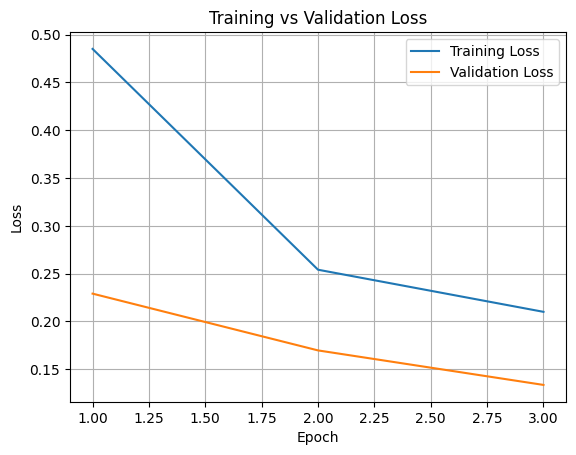

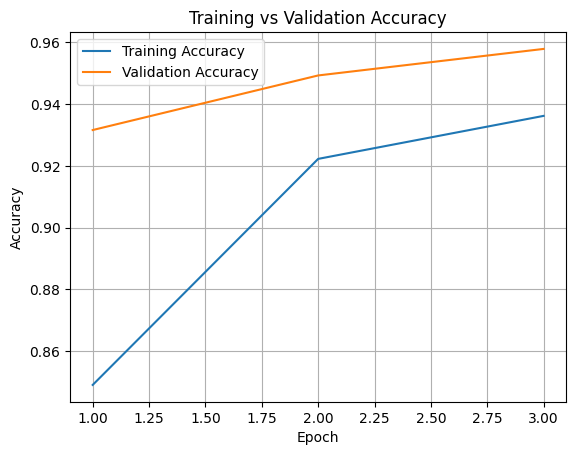

MNIST Test Data
Accuracy: 0.9618
Error Rate: 0.03820000000000001

F1 Score Per Digit:
Digit 0: 0.9796
Digit 1: 0.9815
Digit 2: 0.9598
Digit 3: 0.9635
Digit 4: 0.9591
Digit 5: 0.9576
Digit 6: 0.9610
Digit 7: 0.9506
Digit 8: 0.9537
Digit 9: 0.9490

Confusion Matrix:
[[ 962    0    1    0    0    1   11    2    3    0]
 [   0 1113    5    2    0    0    5    3    7    0]
 [   4    0 1003    0    3    1    4   14    3    0]
 [   0    0   13  964    0   10    0   14    8    1]
 [   1    0    5    0  937    1   13    3    4   18]
 [   5    1    2   12    1  846   10    2    9    4]
 [   4    3    2    0    2    7  936    1    3    0]
 [   1    8   18    2    2    0    0  991    0    6]
 [   3    2    8    4    3    6    8   11  926    3]
 [   4    6    1    7   24    3    3   16    5  940]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       980
           1       0.98      0.98      0.98      1135
           2     

In [21]:
dropout_rate = 0.3
learning_rate = 0.001
epochs = 3
model, figs = try_model(nn.Sequential(
                nn.Linear(784, 256),
                nn.ReLU(),
                nn.Dropout(dropout_rate),
    
                nn.Linear(256, 128),
                nn.ReLU(),
                nn.Dropout(dropout_rate),
    
                nn.Linear(128, 10)
            ),
         dropout_rate,
         learning_rate,
         epochs)

for fig in figs:
    display(fig)

mnist_results = display_mnist_results(model)

Total parameters: 235146
Trainable parameters: 235146
Epoch [1/10] Train Loss: 0.9036, Train Acc: 0.7072, Val Loss: 0.4710, Val Acc: 0.8693
Epoch [2/10] Train Loss: 0.7661, Train Acc: 0.7657, Val Loss: 0.6287, Val Acc: 0.8184
Epoch [3/10] Train Loss: 0.7624, Train Acc: 0.7676, Val Loss: 0.4335, Val Acc: 0.8779
Epoch [4/10] Train Loss: 0.7401, Train Acc: 0.7768, Val Loss: 0.4503, Val Acc: 0.8720
Epoch [5/10] Train Loss: 0.7576, Train Acc: 0.7728, Val Loss: 0.4104, Val Acc: 0.8832
Epoch [6/10] Train Loss: 0.7452, Train Acc: 0.7725, Val Loss: 0.4056, Val Acc: 0.8928
Epoch [7/10] Train Loss: 0.7230, Train Acc: 0.7850, Val Loss: 0.4246, Val Acc: 0.8804
Epoch [8/10] Train Loss: 0.7367, Train Acc: 0.7818, Val Loss: 0.4416, Val Acc: 0.8708
Epoch [9/10] Train Loss: 0.7467, Train Acc: 0.7784, Val Loss: 0.3793, Val Acc: 0.8958
Epoch [10/10] Train Loss: 0.7339, Train Acc: 0.7853, Val Loss: 0.4530, Val Acc: 0.8798


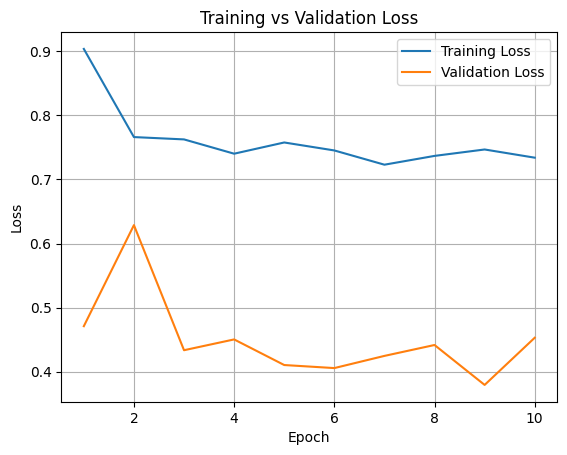

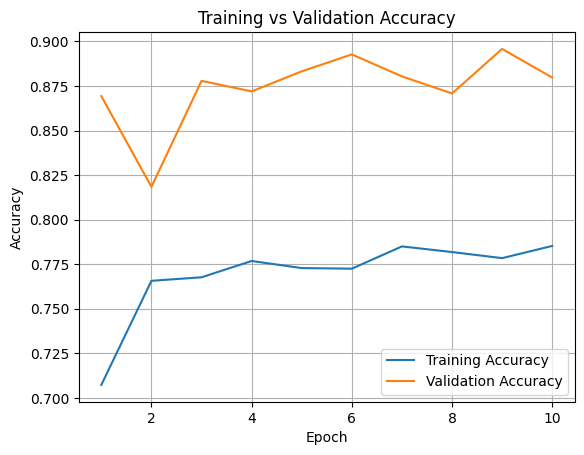

In [22]:
dropout_rate = 0.3
learning_rate = 0.01
epochs = 10
model, figs = try_model(nn.Sequential(
                nn.Linear(784, 256),
                nn.ReLU(),
                nn.Dropout(dropout_rate),
    
                nn.Linear(256, 128),
                nn.ReLU(),
                nn.Dropout(dropout_rate),
    
                nn.Linear(128, 10)
            ),
         dropout_rate,
         learning_rate,
         epochs)

for fig in figs:
    display(fig)

Total parameters: 1068810
Trainable parameters: 1068810
Epoch [1/3] Train Loss: 0.3929, Train Acc: 0.8766, Val Loss: 0.2103, Val Acc: 0.9353
Epoch [2/3] Train Loss: 0.2099, Train Acc: 0.9365, Val Loss: 0.1637, Val Acc: 0.9497
Epoch [3/3] Train Loss: 0.1756, Train Acc: 0.9463, Val Loss: 0.1584, Val Acc: 0.9530


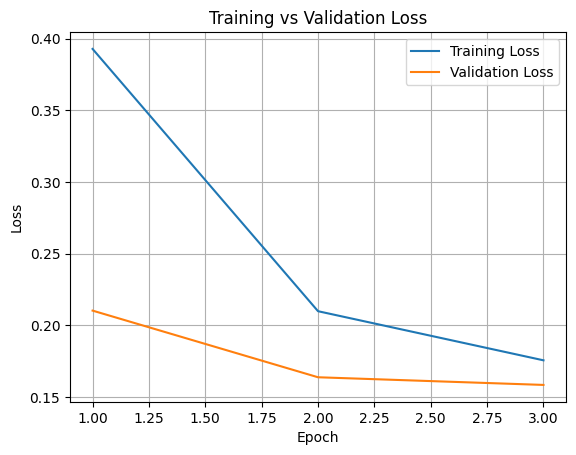

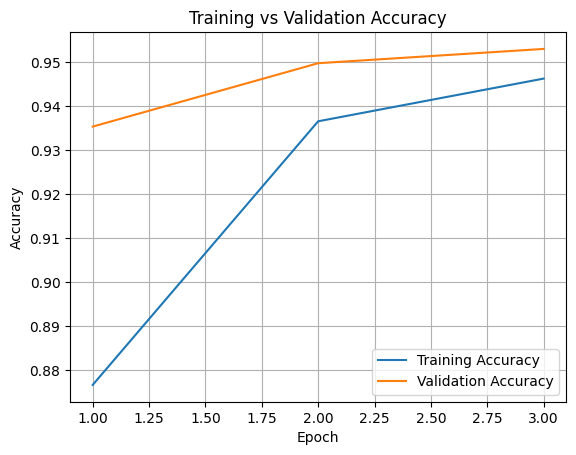

MNIST Test Data
Accuracy: 0.9592
Error Rate: 0.04079999999999995

F1 Score Per Digit:
Digit 0: 0.9793
Digit 1: 0.9683
Digit 2: 0.9665
Digit 3: 0.9605
Digit 4: 0.9501
Digit 5: 0.9594
Digit 6: 0.9687
Digit 7: 0.9560
Digit 8: 0.9522
Digit 9: 0.9306

Confusion Matrix:
[[ 970    1    0    1    0    2    3    1    2    0]
 [   0 1130    1    1    0    0    0    0    3    0]
 [   8   12  982    7    5    0    1   13    4    0]
 [   0    8    3  961    0   13    0   10    2   13]
 [   1    5    3    0  913    0    2    7    0   51]
 [   4    6    0    5    2  851    6    6    5    7]
 [   8    7    3    1   11    7  912    1    8    0]
 [   1   14    7    0    0    0    0 1000    0    6]
 [   4   10    1    8    4    8    1    7  907   24]
 [   5    6    0    7    5    1    0   19    0  966]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       980
           1       0.94      1.00      0.97      1135
           2     

In [23]:
dropout_rate = 0.3
learning_rate = 0.001
epochs = 3
model, figs = try_model(nn.Sequential(
                nn.Linear(784, 1024),
                nn.ReLU(),
                nn.Dropout(dropout_rate),
    
                nn.Linear(1024, 256),
                nn.ReLU(),
                nn.Dropout(dropout_rate),
    
                nn.Linear(256, 10)
            ),
         dropout_rate,
         learning_rate,
         epochs)

for fig in figs:
    display(fig)

mnist_results = display_mnist_results(model)

Total parameters: 1068810
Trainable parameters: 1068810
Epoch [1/10] Train Loss: 0.3910, Train Acc: 0.8758, Val Loss: 0.1971, Val Acc: 0.9387
Epoch [2/10] Train Loss: 0.2100, Train Acc: 0.9345, Val Loss: 0.1391, Val Acc: 0.9563
Epoch [3/10] Train Loss: 0.1773, Train Acc: 0.9457, Val Loss: 0.1758, Val Acc: 0.9468
Epoch [4/10] Train Loss: 0.1558, Train Acc: 0.9517, Val Loss: 0.1377, Val Acc: 0.9593
Epoch [5/10] Train Loss: 0.1452, Train Acc: 0.9555, Val Loss: 0.1365, Val Acc: 0.9601
Epoch [6/10] Train Loss: 0.1338, Train Acc: 0.9585, Val Loss: 0.1094, Val Acc: 0.9683
Epoch [7/10] Train Loss: 0.1259, Train Acc: 0.9608, Val Loss: 0.1023, Val Acc: 0.9708
Epoch [8/10] Train Loss: 0.1220, Train Acc: 0.9620, Val Loss: 0.1017, Val Acc: 0.9702
Epoch [9/10] Train Loss: 0.1189, Train Acc: 0.9617, Val Loss: 0.0936, Val Acc: 0.9728
Epoch [10/10] Train Loss: 0.1163, Train Acc: 0.9638, Val Loss: 0.0977, Val Acc: 0.9693


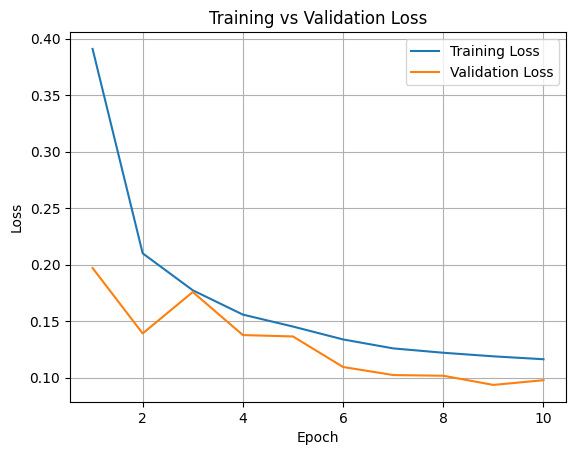

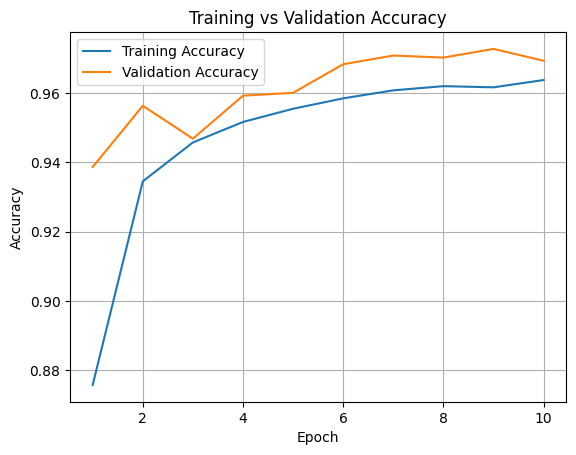

MNIST Test Data
Accuracy: 0.9746
Error Rate: 0.025399999999999978

F1 Score Per Digit:
Digit 0: 0.9857
Digit 1: 0.9881
Digit 2: 0.9743
Digit 3: 0.9688
Digit 4: 0.9770
Digit 5: 0.9763
Digit 6: 0.9775
Digit 7: 0.9667
Digit 8: 0.9695
Digit 9: 0.9613

Confusion Matrix:
[[ 968    1    1    1    0    1    3    1    2    2]
 [   0 1123    1    2    0    0    1    2    6    0]
 [   5    0 1003    3    6    0    2   10    3    0]
 [   0    0    4  992    0    3    0    7    3    1]
 [   0    0    3    0  955    0    7    1    1   15]
 [   2    1    0   14    1  864    3    0    2    5]
 [   4    3    0    1    3    6  936    0    5    0]
 [   0    6   11    2    0    0    0  987    0   22]
 [   2    1    4   13    1    4    3    3  938    5]
 [   3    3    0   10    7    0    2    3    1  980]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2    

In [24]:
dropout_rate = 0.3
learning_rate = 0.001
epochs = 10
model, figs = try_model(nn.Sequential(
                nn.Linear(784, 1024),
                nn.ReLU(),
                nn.Dropout(dropout_rate),
    
                nn.Linear(1024, 256),
                nn.ReLU(),
                nn.Dropout(dropout_rate),
    
                nn.Linear(256, 10)
            ),
         dropout_rate,
         learning_rate,
         epochs)

for fig in figs:
    display(fig)

mnist_results = display_mnist_results(model)

In [25]:
save_model(model, "large_precise_model.pth")

Saved model as large_precise_model.pth


In [26]:
custom_results = display_custom_results(model)

Group Collected Digit Images - Per Group

Group 1
------------------------------
Number of images: 20
Accuracy: 0.25
Error Rate: 0.75
Macro F1 Score: 0.25

Group 2
------------------------------
Number of images: 28
Accuracy: 0.39285714285714285
Error Rate: 0.6071428571428572
Macro F1 Score: 0.38380952380952377

Group 3
------------------------------
Number of images: 40
Accuracy: 0.35
Error Rate: 0.65
Macro F1 Score: 0.3419047619047619

Group 4
------------------------------
Number of images: 30
Accuracy: 0.5666666666666667
Error Rate: 0.43333333333333335
Macro F1 Score: 0.5833333333333334

Group 5
------------------------------
Number of images: 30
Accuracy: 0.6666666666666666
Error Rate: 0.33333333333333337
Macro F1 Score: 0.6154761904761904

Group 6
------------------------------
Number of images: 30
Accuracy: 0.6666666666666666
Error Rate: 0.33333333333333337
Macro F1 Score: 0.6002380952380951

Group 7
------------------------------
Number of images: 30
Accuracy: 0.566666666666666

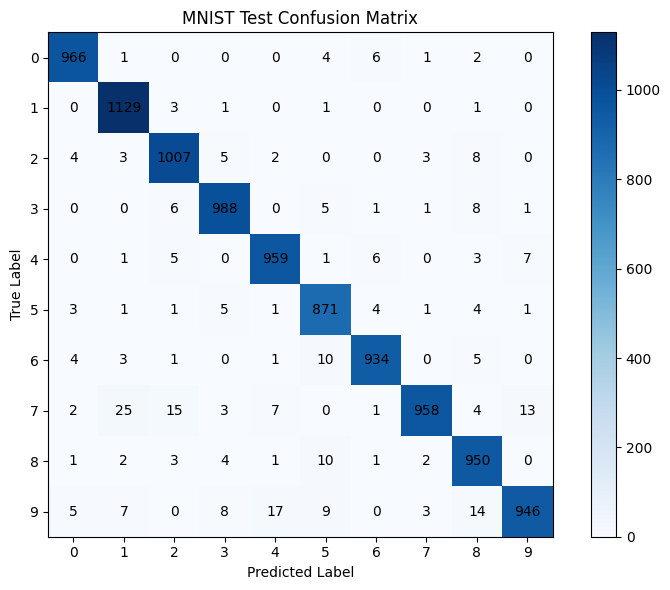

In [42]:
display_confusion_matrix(mnist_results)

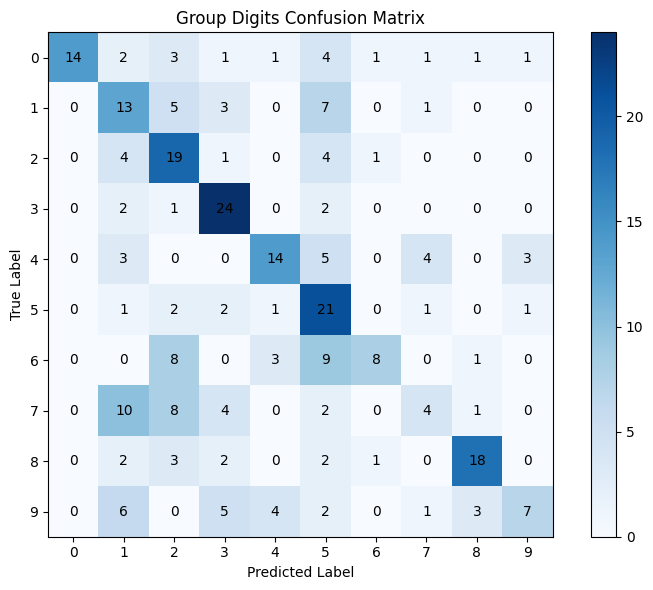

In [50]:
if custom_results is not None:
    combined_cm = np.zeros((10, 10), dtype=int)

    for group_id in sorted(custom_results.keys()):
        combined_cm += custom_results[group_id]["confusion_matrix"]

    fig = plot_confusion_matrix(
        combined_cm,
        title="Group Digits Confusion Matrix"
    )
    display(fig)

Total parameters: 1068810
Trainable parameters: 1068810
Epoch [1/3] Train Loss: 0.5628, Train Acc: 0.8241, Val Loss: 0.3204, Val Acc: 0.9089
Epoch [2/3] Train Loss: 0.4116, Train Acc: 0.8760, Val Loss: 0.3388, Val Acc: 0.8903
Epoch [3/3] Train Loss: 0.4049, Train Acc: 0.8776, Val Loss: 0.2922, Val Acc: 0.9187


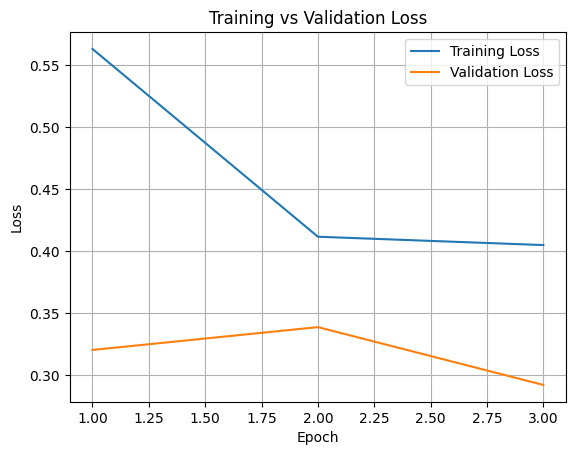

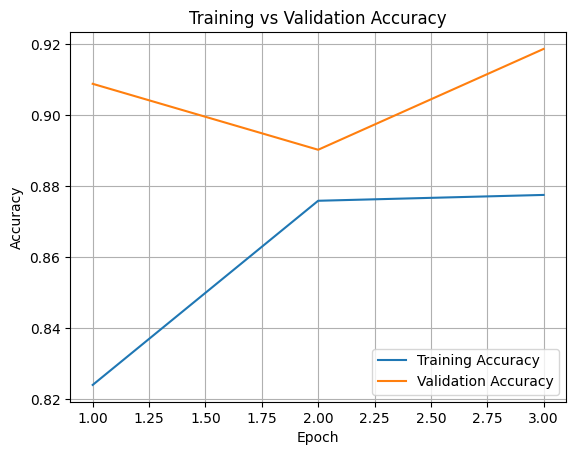

MNIST Test Data
Accuracy: 0.9194
Error Rate: 0.0806

F1 Score Per Digit:
Digit 0: 0.9420
Digit 1: 0.9422
Digit 2: 0.9288
Digit 3: 0.9175
Digit 4: 0.9297
Digit 5: 0.8928
Digit 6: 0.9266
Digit 7: 0.9046
Digit 8: 0.8935
Digit 9: 0.9061

Confusion Matrix:
[[ 966    0    2    1    0    4    3    4    0    0]
 [   0 1124    2    2    0    1    4    2    0    0]
 [  16   13  939   11   12    1   15   22    3    0]
 [   5    5   15  934    1   18    4   24    3    1]
 [   1   11    4    0  919    1   15    5    1   25]
 [  19   11    2   30    3  766   20   29    5    7]
 [  32    7    2    0    6   12  896    1    2    0]
 [   2   19   17    2    4    0    1  981    0    2]
 [  17   48    6   33    9   19   17   20  801    4]
 [  13   13    1   13   41    2    1   53    4  868]]

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.99      0.94       980
           1       0.90      0.99      0.94      1135
           2       0.95      0

In [28]:
dropout_rate = 0.3
learning_rate = 0.005
epochs = 3
model, figs = try_model(nn.Sequential(
                nn.Linear(784, 1024),
                nn.Sigmoid(),
                nn.Dropout(dropout_rate),
    
                nn.Linear(1024, 256),
                nn.Sigmoid(),
                nn.Dropout(dropout_rate),
    
                nn.Linear(256, 10)
            ),
         dropout_rate,
         learning_rate,
         epochs)

for fig in figs:
    display(fig)

mnist_results = display_mnist_results(model)

Total parameters: 235146
Trainable parameters: 235146
Epoch [1/3] Train Loss: 0.6715, Train Acc: 0.8166, Val Loss: 0.2998, Val Acc: 0.9114
Epoch [2/3] Train Loss: 0.2910, Train Acc: 0.9155, Val Loss: 0.2237, Val Acc: 0.9298
Epoch [3/3] Train Loss: 0.2295, Train Acc: 0.9325, Val Loss: 0.1717, Val Acc: 0.9479


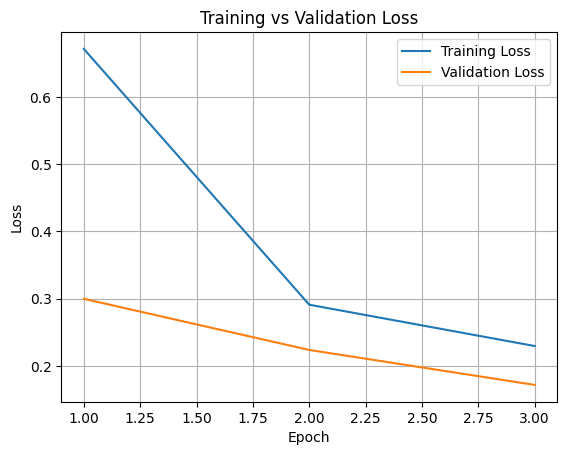

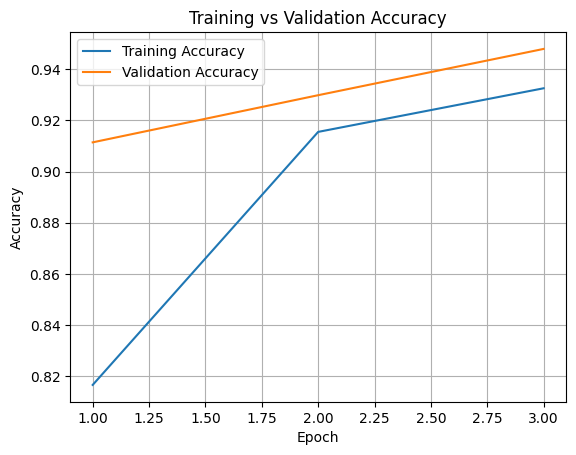

MNIST Test Data
Accuracy: 0.9517
Error Rate: 0.04830000000000001

F1 Score Per Digit:
Digit 0: 0.9734
Digit 1: 0.9786
Digit 2: 0.9515
Digit 3: 0.9489
Digit 4: 0.9501
Digit 5: 0.9320
Digit 6: 0.9527
Digit 7: 0.9466
Digit 8: 0.9412
Digit 9: 0.9360

Confusion Matrix:
[[ 970    0    0    1    0    5    0    1    2    1]
 [   0 1121    1    3    1    1    3    2    3    0]
 [  10    6  961   11   10    0    8   17    9    0]
 [   0    1    7  956    0   20    0   13    9    4]
 [   1    1    3    0  943    1   11    2    2   18]
 [   7    2    0   11    2  843    7    4   10    6]
 [  12    3    3    0    6   25  906    0    3    0]
 [   2   12   11    3    3    0    0  984    0   13]
 [   4    4    2   12   10   15    8   10  904    5]
 [   7    6    0    8   28    7    1   18    5  929]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.99      0.97       980
           1       0.97      0.99      0.98      1135
           2     

In [29]:
dropout_rate = 0.3
learning_rate = 0.001
epochs = 3
model, figs = try_model(nn.Sequential(
                nn.Linear(784, 256),
                nn.Sigmoid(),
                nn.Dropout(dropout_rate),
    
                nn.Linear(256, 128),
                nn.Sigmoid(),
                nn.Dropout(dropout_rate),
    
                nn.Linear(128, 10)
            ),
         dropout_rate,
         learning_rate,
         epochs)

for fig in figs:
    display(fig)

mnist_results = display_mnist_results(model)

Total parameters: 104938
Trainable parameters: 104938
Epoch [1/3] Train Loss: 1.1272, Train Acc: 0.7002, Val Loss: 0.4626, Val Acc: 0.8878
Epoch [2/3] Train Loss: 0.4848, Train Acc: 0.8742, Val Loss: 0.2993, Val Acc: 0.9180
Epoch [3/3] Train Loss: 0.3793, Train Acc: 0.8983, Val Loss: 0.2450, Val Acc: 0.9296


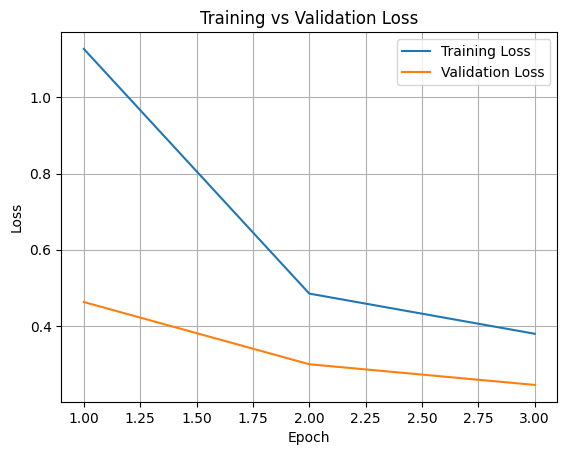

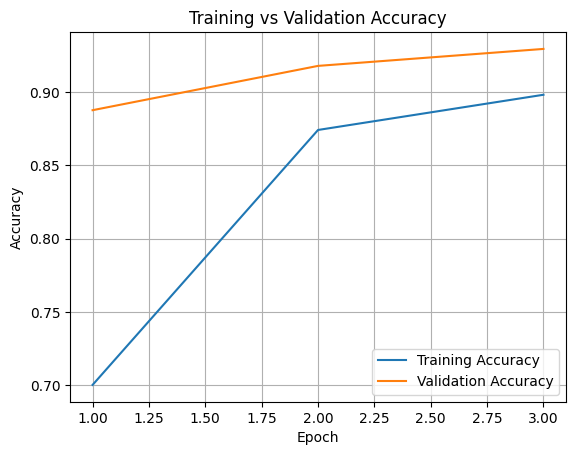

MNIST Test Data
Accuracy: 0.9335
Error Rate: 0.0665

F1 Score Per Digit:
Digit 0: 0.9648
Digit 1: 0.9742
Digit 2: 0.9344
Digit 3: 0.9241
Digit 4: 0.9325
Digit 5: 0.8878
Digit 6: 0.9453
Digit 7: 0.9276
Digit 8: 0.9240
Digit 9: 0.9083

Confusion Matrix:
[[ 960    0    1    1    0    6   10    1    1    0]
 [   0 1113    2    3    0    0    3    1   12    1]
 [   9    5  955    4   12    1   13   16   16    1]
 [   2    1   22  943    0   12    0   17    9    4]
 [   1    1    4    0  912    0   12    2    3   47]
 [  11    3    3   50    9  740   22    5   32   17]
 [  10    3    5    0    8    5  924    1    2    0]
 [   3   14   16    4    3    0    0  941    0   47]
 [   5    5    3   15    7    7   12    9  906    5]
 [   9    5    1   11   23    4    1    8    6  941]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.98      0.96       980
           1       0.97      0.98      0.97      1135
           2       0.94      0

In [30]:
dropout_rate = 0.3
learning_rate = 0.001
epochs = 3
model, figs = try_model(nn.Sequential(
                nn.Linear(784, 128),
                nn.Sigmoid(),
                nn.Dropout(dropout_rate),
    
                nn.Linear(128, 32),
                nn.Sigmoid(),
                nn.Dropout(dropout_rate),
    
                nn.Linear(32, 10)
            ),
         dropout_rate,
         learning_rate,
         epochs)

for fig in figs:
    display(fig)

mnist_results = display_mnist_results(model)

Total parameters: 25450
Trainable parameters: 25450
Epoch [1/3] Train Loss: 0.9903, Train Acc: 0.7590, Val Loss: 0.4787, Val Acc: 0.8873
Epoch [2/3] Train Loss: 0.5056, Train Acc: 0.8628, Val Loss: 0.3495, Val Acc: 0.9052
Epoch [3/3] Train Loss: 0.4281, Train Acc: 0.8799, Val Loss: 0.2986, Val Acc: 0.9157


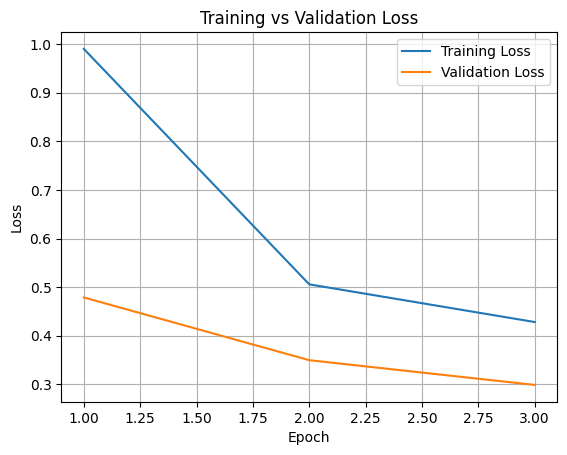

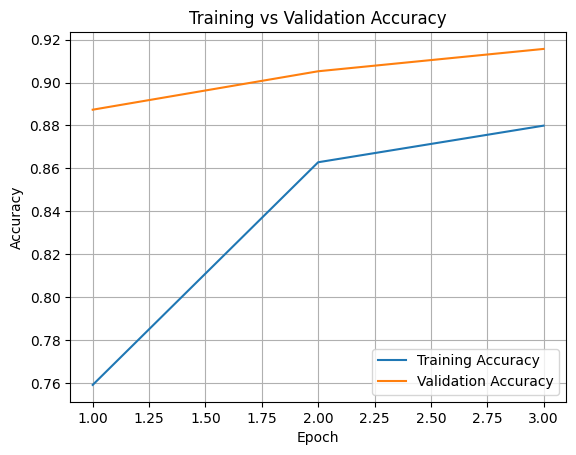

MNIST Test Data
Accuracy: 0.9194
Error Rate: 0.0806

F1 Score Per Digit:
Digit 0: 0.9555
Digit 1: 0.9642
Digit 2: 0.9158
Digit 3: 0.8996
Digit 4: 0.9214
Digit 5: 0.8805
Digit 6: 0.9411
Digit 7: 0.9169
Digit 8: 0.8890
Digit 9: 0.8987

Confusion Matrix:
[[ 945    0    5    1    1   12   12    1    3    0]
 [   0 1104    2    4    1    0    5    2   17    0]
 [  10    4  935   16   17    0   12   11   25    2]
 [   3    1   23  923    0   19    3   11   21    6]
 [   1    1    4    0  938    0   12    1    4   21]
 [   9    2    5   53    8  755   18    7   29    6]
 [  13    4    4    0    8    8  919    0    2    0]
 [   3   24   23    6   12    1    0  910    2   47]
 [   6    8    7   27   11   21   12    6  869    7]
 [   8    7    2   12   58    7    2    8    9  896]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.96      0.96       980
           1       0.96      0.97      0.96      1135
           2       0.93      0

In [31]:
dropout_rate = 0.3
learning_rate = 0.001
epochs = 3
model, figs = try_model(nn.Sequential(
                nn.Linear(784, 32),
                nn.Sigmoid(),
                nn.Dropout(dropout_rate),
    
                nn.Linear(32, 10)
            ),
         dropout_rate,
         learning_rate,
         epochs)

for fig in figs:
    display(fig)

mnist_results = display_mnist_results(model)

Total parameters: 25450
Trainable parameters: 25450
Epoch [1/3] Train Loss: 0.8458, Train Acc: 0.7307, Val Loss: 0.3841, Val Acc: 0.8915
Epoch [2/3] Train Loss: 0.5604, Train Acc: 0.8181, Val Loss: 0.3154, Val Acc: 0.9087
Epoch [3/3] Train Loss: 0.5173, Train Acc: 0.8337, Val Loss: 0.3001, Val Acc: 0.9123


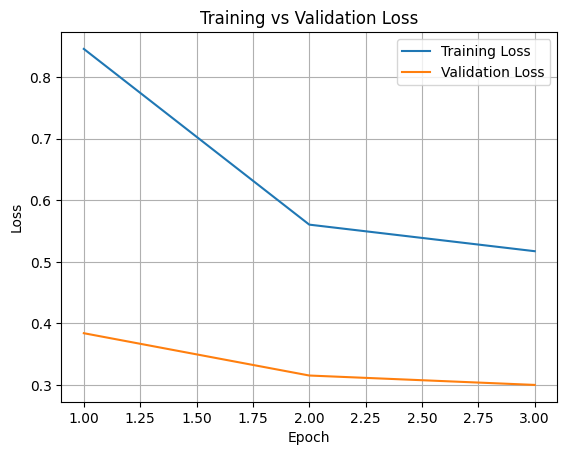

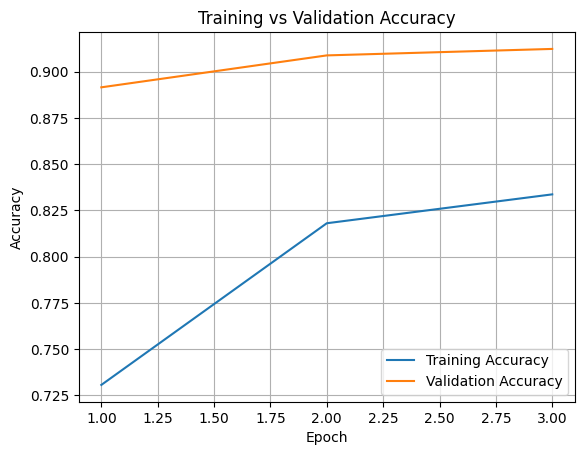

MNIST Test Data
Accuracy: 0.9186
Error Rate: 0.08140000000000003

F1 Score Per Digit:
Digit 0: 0.9576
Digit 1: 0.9725
Digit 2: 0.9114
Digit 3: 0.9008
Digit 4: 0.9103
Digit 5: 0.8549
Digit 6: 0.9458
Digit 7: 0.9229
Digit 8: 0.8900
Digit 9: 0.9019

Confusion Matrix:
[[ 960    0    3    1    2    5    6    1    2    0]
 [   0 1112    1    5    1    0    4    2   10    0]
 [   9    5  931   13   16    0    8   16   33    1]
 [   1    1   24  940    2   12    1   14   10    5]
 [   1    0    8    1  934    1    7    2    5   23]
 [  19    1    3   74   22  698   13   10   42   10]
 [  12    3    7    0   20   10  899    1    6    0]
 [   2   18   20   10    4    0    1  946    1   26]
 [  11    7   12   21   13    9    4   11  874   12]
 [  10    5    2   12   56    6    0   19    7  892]]

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.98      0.96       980
           1       0.97      0.98      0.97      1135
           2     

In [32]:
dropout_rate = 0.3
learning_rate = 0.001
epochs = 3
model, figs = try_model(nn.Sequential(
                nn.Linear(784, 32),
                nn.ReLU(),
                nn.Dropout(dropout_rate),
    
                nn.Linear(32, 10)
            ),
         dropout_rate,
         learning_rate,
         epochs)

for fig in figs:
    display(fig)

mnist_results = display_mnist_results(model)

Total parameters: 5232810
Trainable parameters: 5232810
Epoch [1/3] Train Loss: 0.4660, Train Acc: 0.8650, Val Loss: 0.2195, Val Acc: 0.9351
Epoch [2/3] Train Loss: 0.2286, Train Acc: 0.9313, Val Loss: 0.1828, Val Acc: 0.9428
Epoch [3/3] Train Loss: 0.1896, Train Acc: 0.9421, Val Loss: 0.1835, Val Acc: 0.9434


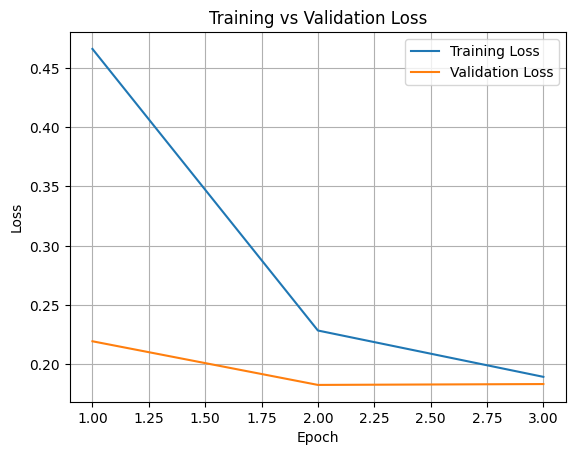

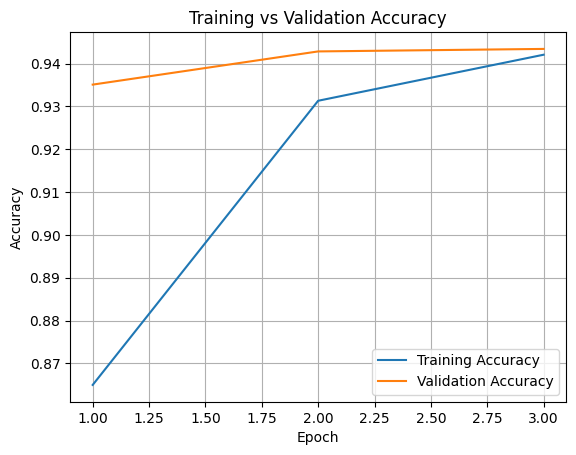

MNIST Test Data
Accuracy: 0.9427
Error Rate: 0.05730000000000002

F1 Score Per Digit:
Digit 0: 0.9729
Digit 1: 0.9807
Digit 2: 0.9543
Digit 3: 0.9344
Digit 4: 0.9333
Digit 5: 0.9109
Digit 6: 0.9474
Digit 7: 0.9467
Digit 8: 0.9202
Digit 9: 0.9181

Confusion Matrix:
[[ 968    0    0    1    0    5    2    1    0    3]
 [   0 1119    1    4    0    1    3    1    6    0]
 [   9    3  971   15    8    1    5   13    6    1]
 [   0    0    2  962    0   30    0    8    2    6]
 [   1    0    3    0  902    1    6    1    2   66]
 [   9    1    1   21    3  843    5    1    3    5]
 [  11    3    4    0   12   35  891    0    2    0]
 [   1   10   16    6    4    0    0  959    0   32]
 [   5    5    4   30   12   36   10   10  848   14]
 [   6    6    1   10   10    7    1    4    0  964]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.99      0.97       980
           1       0.98      0.99      0.98      1135
           2     

In [33]:
dropout_rate = 0.3
learning_rate = 0.001
epochs = 3
model, figs = try_model(nn.Sequential(
                nn.Linear(784, 5024),
                nn.Sigmoid(),
                nn.Dropout(dropout_rate),
    
                nn.Linear(5024, 256),
                nn.Sigmoid(),
                nn.Dropout(dropout_rate),
    
                nn.Linear(256, 10)
            ),
         dropout_rate,
         learning_rate,
         epochs)

for fig in figs:
    display(fig)

mnist_results = display_mnist_results(model)

Total parameters: 7960
Trainable parameters: 7960
Epoch [1/3] Train Loss: 1.5902, Train Acc: 0.4427, Val Loss: 0.8617, Val Acc: 0.7922
Epoch [2/3] Train Loss: 0.9729, Train Acc: 0.6793, Val Loss: 0.5520, Val Acc: 0.8627
Epoch [3/3] Train Loss: 0.8798, Train Acc: 0.7051, Val Loss: 0.5237, Val Acc: 0.8472


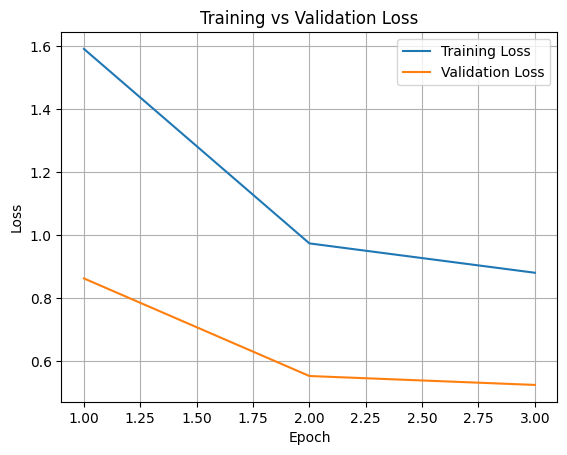

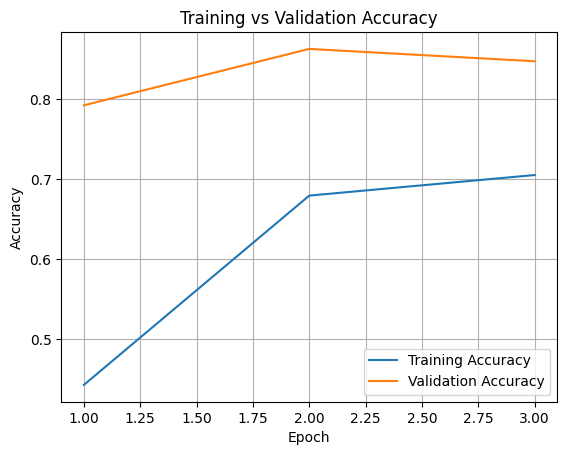

MNIST Test Data
Accuracy: 0.8544
Error Rate: 0.14559999999999995

F1 Score Per Digit:
Digit 0: 0.9187
Digit 1: 0.9458
Digit 2: 0.8818
Digit 3: 0.8482
Digit 4: 0.7009
Digit 5: 0.8096
Digit 6: 0.9014
Digit 7: 0.8913
Digit 8: 0.8364
Digit 9: 0.7685

Confusion Matrix:
[[ 949    0    3    1    0   11    9    3    4    0]
 [   0 1090    5   18    0    2    3    4   12    1]
 [  18   16  865   46    5    8   15   30   22    7]
 [   3    5   12  919    0   31    0   19   16    5]
 [  10    7    3    0  546    0   22   15   10  369]
 [  25    1    6   83    3  691   19   19   42    3]
 [  48    3    6    1   11   21  864    1    3    0]
 [   3   24   24    8    0    0    0  935    1   33]
 [  10   16    5   66    7   37   24    7  782   20]
 [  20    8    1   15    4   14    3   37    4  903]]

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.97      0.92       980
           1       0.93      0.96      0.95      1135
           2     

In [34]:
dropout_rate = 0.3
learning_rate = 0.005
epochs = 3
model, figs = try_model(nn.Sequential(
                nn.Linear(784, 10),
                nn.Sigmoid(),
                nn.Dropout(dropout_rate),
    
                nn.Linear(10, 10)
            ),
         dropout_rate,
         learning_rate,
         epochs)

for fig in figs:
    display(fig)

mnist_results = display_mnist_results(model)

In [35]:
# model = MLP(nn.Sequential(
#                 nn.Linear(784, 1024),
#                 nn.ReLU(),
#                 nn.Dropout(dropout_rate),
    
#                 nn.Linear(1024, 256),
#                 nn.ReLU(),
#                 nn.Dropout(dropout_rate),
    
#                 nn.Linear(256, 10)
#             ), dropout_rate=0.3).to(device)

# state_dict = torch.load('large_precise_model.pth', weights_only=True)

# model.load_state_dict(state_dict)
# model.eval()

# mnist_results = display_mnist_results(model)
# custom_results = display_custom_results(model)

Total parameters: 1068810
Trainable parameters: 1068810
Epoch [1/10] Train Loss: 0.5758, Train Acc: 0.8260, Val Loss: 0.2720, Val Acc: 0.9197
Epoch [2/10] Train Loss: 0.2854, Train Acc: 0.9152, Val Loss: 0.2042, Val Acc: 0.9372
Epoch [3/10] Train Loss: 0.2335, Train Acc: 0.9296, Val Loss: 0.1565, Val Acc: 0.9502
Epoch [4/10] Train Loss: 0.2054, Train Acc: 0.9380, Val Loss: 0.1479, Val Acc: 0.9550
Epoch [5/10] Train Loss: 0.1871, Train Acc: 0.9432, Val Loss: 0.1340, Val Acc: 0.9590
Epoch [6/10] Train Loss: 0.1802, Train Acc: 0.9446, Val Loss: 0.1396, Val Acc: 0.9554
Epoch [7/10] Train Loss: 0.1696, Train Acc: 0.9484, Val Loss: 0.1307, Val Acc: 0.9599
Epoch [8/10] Train Loss: 0.1633, Train Acc: 0.9501, Val Loss: 0.1435, Val Acc: 0.9541
Epoch [9/10] Train Loss: 0.1599, Train Acc: 0.9516, Val Loss: 0.1146, Val Acc: 0.9637
Epoch [10/10] Train Loss: 0.1552, Train Acc: 0.9524, Val Loss: 0.1010, Val Acc: 0.9680


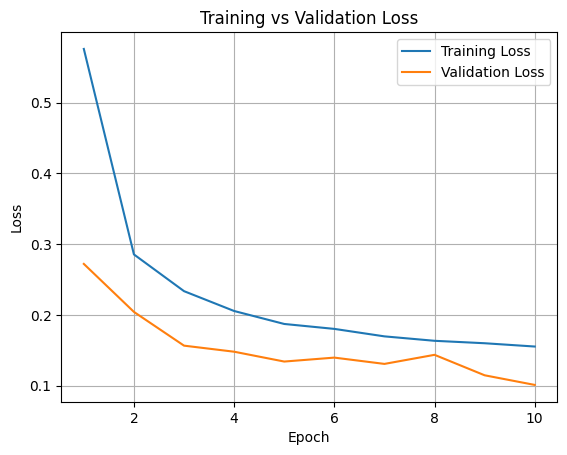

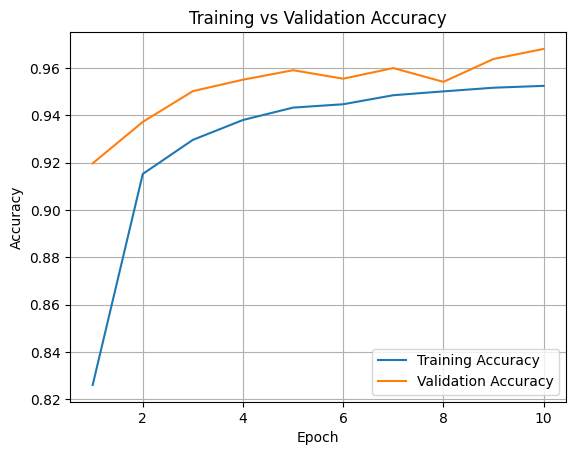

MNIST Test Data
Accuracy: 0.9702
Error Rate: 0.02980000000000005

F1 Score Per Digit:
Digit 0: 0.9787
Digit 1: 0.9872
Digit 2: 0.9686
Digit 3: 0.9672
Digit 4: 0.9707
Digit 5: 0.9645
Digit 6: 0.9685
Digit 7: 0.9679
Digit 8: 0.9640
Digit 9: 0.9620

Confusion Matrix:
[[ 963    0    2    1    0    2    7    3    2    0]
 [   0 1121    3    2    0    0    4    0    5    0]
 [   6    0 1001    4    4    0    3    9    5    0]
 [   0    0    7  988    0    3    0    6    4    2]
 [   1    0    3    0  945    0    7    1    2   23]
 [   5    1    0   18    2  843    9    2    7    5]
 [   5    3    0    0    5    4  937    0    4    0]
 [   1    6   14    4    0    0    0  994    0    9]
 [   3    1    4    8    3    3    9    4  936    3]
 [   4    4    1    8    6    1    1    7    3  974]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.98      0.98       980
           1       0.99      0.99      0.99      1135
           2     

In [36]:
dropout_rate = 0.5
learning_rate = 0.001
epochs = 10
model, figs = try_model(nn.Sequential(
                nn.Linear(784, 1024),
                nn.Sigmoid(),
                nn.Dropout(dropout_rate),
    
                nn.Linear(1024, 256),
                nn.Sigmoid(),
                nn.Dropout(dropout_rate),
    
                nn.Linear(256, 10)
            ),
         dropout_rate,
         learning_rate,
         epochs)

for fig in figs:
    display(fig)

mnist_results = display_mnist_results(model)

In [37]:
custom_results = display_custom_results(model)

Group Collected Digit Images - Per Group

Group 1
------------------------------
Number of images: 20
Accuracy: 0.2
Error Rate: 0.8
Macro F1 Score: 0.17484848484848484

Group 2
------------------------------
Number of images: 28
Accuracy: 0.32142857142857145
Error Rate: 0.6785714285714286
Macro F1 Score: 0.35357142857142854

Group 3
------------------------------
Number of images: 40
Accuracy: 0.3
Error Rate: 0.7
Macro F1 Score: 0.2904256854256854

Group 4
------------------------------
Number of images: 30
Accuracy: 0.5333333333333333
Error Rate: 0.4666666666666667
Macro F1 Score: 0.5344444444444445

Group 5
------------------------------
Number of images: 30
Accuracy: 0.7
Error Rate: 0.30000000000000004
Macro F1 Score: 0.6795238095238096

Group 6
------------------------------
Number of images: 30
Accuracy: 0.6333333333333333
Error Rate: 0.3666666666666667
Macro F1 Score: 0.6061904761904763

Group 7
------------------------------
Number of images: 30
Accuracy: 0.5666666666666667
Erro

Total parameters: 1068810
Trainable parameters: 1068810
Epoch [1/10] Train Loss: 0.4537, Train Acc: 0.8659, Val Loss: 0.2399, Val Acc: 0.9256
Epoch [2/10] Train Loss: 0.1973, Train Acc: 0.9397, Val Loss: 0.1864, Val Acc: 0.9429
Epoch [3/10] Train Loss: 0.1547, Train Acc: 0.9535, Val Loss: 0.1225, Val Acc: 0.9612
Epoch [4/10] Train Loss: 0.1255, Train Acc: 0.9619, Val Loss: 0.1210, Val Acc: 0.9624
Epoch [5/10] Train Loss: 0.1122, Train Acc: 0.9655, Val Loss: 0.1001, Val Acc: 0.9687
Epoch [6/10] Train Loss: 0.1017, Train Acc: 0.9693, Val Loss: 0.1242, Val Acc: 0.9617
Epoch [7/10] Train Loss: 0.0981, Train Acc: 0.9698, Val Loss: 0.1040, Val Acc: 0.9681
Epoch [8/10] Train Loss: 0.0940, Train Acc: 0.9712, Val Loss: 0.0968, Val Acc: 0.9705
Epoch [9/10] Train Loss: 0.0841, Train Acc: 0.9741, Val Loss: 0.1025, Val Acc: 0.9687
Epoch [10/10] Train Loss: 0.0840, Train Acc: 0.9732, Val Loss: 0.1104, Val Acc: 0.9669


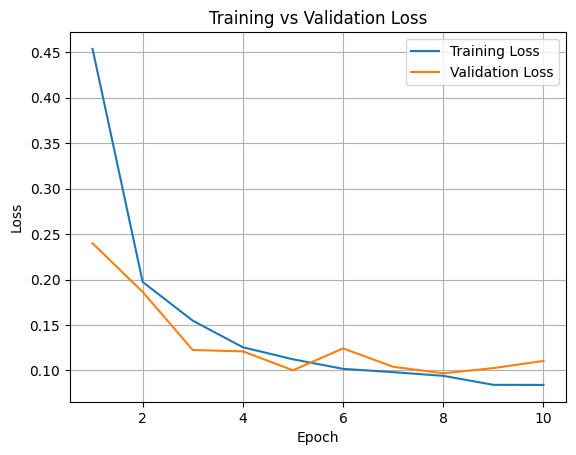

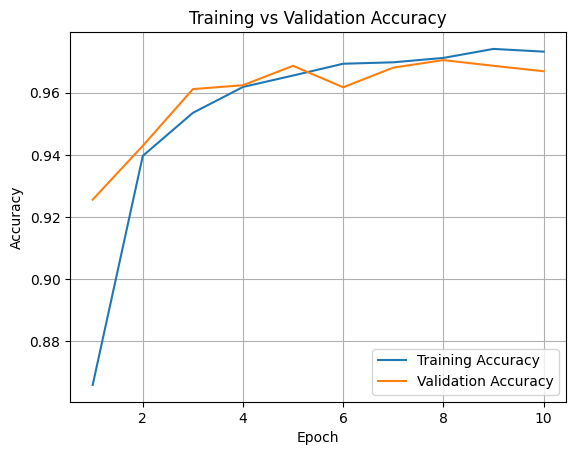

MNIST Test Data
Accuracy: 0.9708
Error Rate: 0.029200000000000004

F1 Score Per Digit:
Digit 0: 0.9832
Digit 1: 0.9788
Digit 2: 0.9715
Digit 3: 0.9763
Digit 4: 0.9736
Digit 5: 0.9662
Digit 6: 0.9775
Digit 7: 0.9594
Digit 8: 0.9630
Digit 9: 0.9570

Confusion Matrix:
[[ 966    1    0    0    0    4    6    1    2    0]
 [   0 1129    3    1    0    1    0    0    1    0]
 [   4    3 1007    5    2    0    0    3    8    0]
 [   0    0    6  988    0    5    1    1    8    1]
 [   0    1    5    0  959    1    6    0    3    7]
 [   3    1    1    5    1  871    4    1    4    1]
 [   4    3    1    0    1   10  934    0    5    0]
 [   2   25   15    3    7    0    1  958    4   13]
 [   1    2    3    4    1   10    1    2  950    0]
 [   5    7    0    8   17    9    0    3   14  946]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.98       980
           1       0.96      0.99      0.98      1135
           2    

In [38]:
dropout_rate = 0.1
learning_rate = 0.001
epochs = 10
model, figs = try_model(nn.Sequential(
                nn.Linear(784, 1024),
                nn.Sigmoid(),
                nn.Dropout(dropout_rate),
    
                nn.Linear(1024, 256),
                nn.Sigmoid(),
                nn.Dropout(dropout_rate),
    
                nn.Linear(256, 10)
            ),
         dropout_rate,
         learning_rate,
         epochs)

for fig in figs:
    display(fig)

mnist_results = display_mnist_results(model)

In [39]:
custom_results = display_custom_results(model)

Group Collected Digit Images - Per Group

Group 1
------------------------------
Number of images: 20
Accuracy: 0.15
Error Rate: 0.85
Macro F1 Score: 0.12205128205128206

Group 2
------------------------------
Number of images: 28
Accuracy: 0.35714285714285715
Error Rate: 0.6428571428571428
Macro F1 Score: 0.35523809523809524

Group 3
------------------------------
Number of images: 40
Accuracy: 0.35
Error Rate: 0.65
Macro F1 Score: 0.31913419913419916

Group 4
------------------------------
Number of images: 30
Accuracy: 0.6
Error Rate: 0.4
Macro F1 Score: 0.5809523809523809

Group 5
------------------------------
Number of images: 30
Accuracy: 0.6
Error Rate: 0.4
Macro F1 Score: 0.5618253968253969

Group 6
------------------------------
Number of images: 30
Accuracy: 0.6
Error Rate: 0.4
Macro F1 Score: 0.5795238095238096

Group 7
------------------------------
Number of images: 30
Accuracy: 0.6333333333333333
Error Rate: 0.3666666666666667
Macro F1 Score: 0.650952380952381

Group 8
-